# 23. Regime-Aware Dynamic Trading System

## Objective
Build a production-style trading system using **regime-specific models** and **multi-horizon signals**:

- **HIGH** regime -> Transformer (**t+1**)
- **MEDIUM** regime -> XGBoost (**t+3**)
- **LOW** regime -> XGBoost (**t+5**)

The notebook routes each row by regime, generates probabilities, normalizes signal strength daily, selects top 10% trades, sizes long/short positions, backtests performance, compares with Buy & Hold and Step-20 best strategy, evaluates by regime, and saves final output.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple
import json
import logging

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 240)

TRAIN_START = pd.Timestamp('2023-01-01')
TRAIN_END = pd.Timestamp('2024-12-31')
INFER_START = pd.Timestamp('2025-01-01')
INFER_END = pd.Timestamp('2025-12-30')

REGIMES = ['LOW', 'MEDIUM', 'HIGH']
HORIZON_MAP = {'LOW': 5, 'MEDIUM': 3, 'HIGH': 1}
TOP_PCT = 0.10
CENTER_Q = 0.55
ANNUALIZATION_DAYS = 252

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger = logging.getLogger('regime_aware_dynamic_strategy')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)

print(f'Using device: {DEVICE}')


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int) -> None:
        super().__init__()
        self.pe = nn.Parameter(torch.zeros(1, max_len, d_model))
        nn.init.normal_(self.pe, mean=0.0, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1), :]


class TransformerClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        d_model: int = 64,
        n_heads: int = 4,
        num_layers: int = 2,
        dropout: float = 0.2,
        max_len: int = 20,
    ) -> None:
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model=d_model, max_len=max_len)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dropout=dropout,
            batch_first=True,
            dim_feedforward=d_model * 4,
            activation='gelu',
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.input_proj(x)
        h = self.pos_enc(h)
        h = self.encoder(h)
        pooled = h.mean(dim=1)
        return self.head(self.dropout(pooled)).squeeze(-1)


Using device: cpu


In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to locate project root.')


def normalize_regime(df_in: pd.DataFrame) -> pd.Series:
    if 'volatility_regime_label' in df_in.columns:
        reg = df_in['volatility_regime_label'].astype(str).str.upper()
        reg = reg.replace({'STABLE': 'MEDIUM', 'NON-VOLATILE': 'LOW', 'NON_VOLATILE': 'LOW'})
        return reg

    assert 'Volatility_20' in df_in.columns, 'Need volatility_regime_label or Volatility_20 to infer regime.'
    train_mask = (df_in['Date'] >= TRAIN_START) & (df_in['Date'] <= TRAIN_END)
    q1 = float(df_in.loc[train_mask, 'Volatility_20'].quantile(1 / 3))
    q2 = float(df_in.loc[train_mask, 'Volatility_20'].quantile(2 / 3))

    def _map(v: float) -> str:
        if v <= q1:
            return 'LOW'
        if v <= q2:
            return 'MEDIUM'
        return 'HIGH'

    return df_in['Volatility_20'].map(_map)


def predict_xgb(model, frame: pd.DataFrame, feature_cols: List[str]) -> pd.Series:
    pred = pd.Series(np.nan, index=frame.index, dtype=float)
    valid = frame[feature_cols].notna().all(axis=1)
    if valid.any():
        pred.loc[valid] = model.predict_proba(frame.loc[valid, feature_cols])[:, 1]
    return pred


def predict_transformer(
    model: nn.Module,
    scaler,
    frame: pd.DataFrame,
    feature_cols: List[str],
    sequence_window: int,
) -> pd.Series:
    pred = pd.Series(np.nan, index=frame.index, dtype=float)
    ordered = frame.sort_values(['Ticker', 'Date']).copy()
    valid_rows = ordered[feature_cols].notna().all(axis=1)
    if not valid_rows.any():
        return pred

    scaled = np.full((len(ordered), len(feature_cols)), np.nan, dtype=np.float32)
    scaled_idx = ordered.index[valid_rows]
    scaled_vals = scaler.transform(ordered.loc[valid_rows, feature_cols]).astype(np.float32)
    scaled[np.isin(ordered.index, scaled_idx)] = scaled_vals
    scaled_df = pd.DataFrame(scaled, index=ordered.index, columns=feature_cols)

    seq_x: List[np.ndarray] = []
    seq_index: List[int] = []
    for _, grp in ordered.groupby('Ticker', sort=False):
        vals = scaled_df.loc[grp.index, feature_cols].to_numpy(dtype=np.float32)
        regs = grp['regime_label'].to_numpy()
        idxs = grp.index.to_numpy()
        if len(grp) < sequence_window:
            continue

        for i in range(sequence_window - 1, len(grp)):
            if regs[i] != 'HIGH':
                continue
            window = vals[i - sequence_window + 1: i + 1]
            if np.isnan(window).any():
                continue
            seq_x.append(window)
            seq_index.append(int(idxs[i]))

    if not seq_x:
        return pred

    x = torch.from_numpy(np.asarray(seq_x, dtype=np.float32)).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(x)).cpu().numpy()
    pred.loc[seq_index] = probs
    return pred


ROOT = resolve_project_root()
BASE = ROOT / 'ml_pipeline'

DATA_PATH = BASE / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet'
STEP20_PATH = BASE / 'Market_Data' / 'final' / 'final_strategy_results.parquet'
OUT_PATH = BASE / 'Market_Data' / 'final' / 'final_regime_aware_strategy.parquet'
MODELS_DIR = BASE / 'models' / 'multi_horizon_regime'

assert DATA_PATH.exists(), f'Missing dataset: {DATA_PATH}'
assert STEP20_PATH.exists(), f'Missing Step-20 strategy file: {STEP20_PATH}'

artifact_map = {
    'HIGH': {
        'meta': MODELS_DIR / 'best_high_transformer_t1_meta.json',
        'expected_model': 'Transformer',
        'expected_horizon': 't+1',
    },
    'MEDIUM': {
        'meta': MODELS_DIR / 'best_medium_xgboost_t3_meta.json',
        'expected_model': 'XGBoost',
        'expected_horizon': 't+3',
    },
    'LOW': {
        'meta': MODELS_DIR / 'best_low_xgboost_t5_meta.json',
        'expected_model': 'XGBoost',
        'expected_horizon': 't+5',
    },
}

bundle: Dict[str, Dict[str, object]] = {}
for reg, cfg in artifact_map.items():
    meta_path = cfg['meta']
    assert meta_path.exists(), f'Missing metadata file: {meta_path}'
    meta = json.loads(meta_path.read_text(encoding='utf-8'))
    assert meta['regime'] == reg
    assert meta['model'] == cfg['expected_model']
    assert meta['horizon'] == cfg['expected_horizon']

    if meta['model'] == 'XGBoost':
        model = joblib.load(meta['model_path'])
        bundle[reg] = {'meta': meta, 'model': model}
    else:
        scaler_path = meta['extra_paths'][0]
        scaler = joblib.load(scaler_path)
        model = TransformerClassifier(
            input_size=len(meta['feature_cols']),
            max_len=int(meta['sequence_window']),
        ).to(DEVICE)
        state = torch.load(meta['model_path'], map_location=DEVICE)
        model.load_state_dict(state)
        bundle[reg] = {'meta': meta, 'model': model, 'scaler': scaler}

logger.info('Loaded regime model artifacts from %s', MODELS_DIR)

df = pd.read_parquet(DATA_PATH).copy()
df['Date'] = pd.to_datetime(df['Date'], errors='raise')
df['Ticker'] = df['Ticker'].astype(str)
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)
df['regime_label'] = normalize_regime(df)
df = df[df['regime_label'].isin(REGIMES)].copy()

for h in [1, 3, 5]:
    df[f'fwd_ret_t{h}'] = df.groupby('Ticker', sort=False)['Close'].shift(-h) / df['Close'] - 1.0

infer_df = df[(df['Date'] >= INFER_START) & (df['Date'] <= INFER_END)].copy()
infer_df['horizon_days'] = infer_df['regime_label'].map(HORIZON_MAP).astype(int)

all_features = sorted({
    f
    for reg in REGIMES
    for f in bundle[reg]['meta']['feature_cols']
})
missing_features = [c for c in all_features if c not in infer_df.columns]
assert not missing_features, f'Missing required features: {missing_features[:10]}'

infer_df['probability'] = np.nan

for reg in ['LOW', 'MEDIUM']:
    reg_mask = infer_df['regime_label'] == reg
    if not reg_mask.any():
        continue
    reg_meta = bundle[reg]['meta']
    reg_model = bundle[reg]['model']
    reg_features = reg_meta['feature_cols']
    infer_df.loc[reg_mask, 'probability'] = predict_xgb(reg_model, infer_df.loc[reg_mask], reg_features)

high_meta = bundle['HIGH']['meta']
high_model = bundle['HIGH']['model']
high_scaler = bundle['HIGH']['scaler']
high_prob = predict_transformer(
    model=high_model,
    scaler=high_scaler,
    frame=infer_df,
    feature_cols=high_meta['feature_cols'],
    sequence_window=int(high_meta['sequence_window']),
)
high_mask = infer_df['regime_label'] == 'HIGH'
infer_df.loc[high_mask, 'probability'] = high_prob.loc[infer_df.loc[high_mask].index]

infer_df['future_return'] = np.select(
    [
        infer_df['horizon_days'] == 1,
        infer_df['horizon_days'] == 3,
        infer_df['horizon_days'] == 5,
    ],
    [infer_df['fwd_ret_t1'], infer_df['fwd_ret_t3'], infer_df['fwd_ret_t5']],
    default=np.nan,
)

infer_df = infer_df.dropna(subset=['probability', 'future_return']).copy()
infer_df = infer_df.sort_values(['Date', 'Ticker']).reset_index(drop=True)

logger.info('Inference rows available: %s', f'{len(infer_df):,}')
display(infer_df[['Ticker', 'Date', 'regime_label', 'horizon_days', 'probability', 'future_return']].head(12))


[INFO] Loaded regime model artifacts from c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\models\multi_horizon_regime
[INFO] Inference rows available: 22,643


,Ticker,Date,regime_label,horizon_days,probability,future_return
0,ADANIPORTS,2025-01-01,MEDIUM,3,0.434885,-0.045663
1,AMBUJACEM,2025-01-01,LOW,5,0.167199,-0.001021
2,APOLLOHOSP,2025-01-01,LOW,5,0.443704,-0.030802
3,ASIANPAINT,2025-01-01,LOW,5,0.515369,0.012887
4,AXISBANK,2025-01-01,LOW,5,0.511351,0.002939
5,BAJAJ-AUTO,2025-01-01,LOW,5,0.563529,-0.011246
6,BAJAJFINSV,2025-01-01,LOW,5,0.425238,0.076503
7,BAJFINANCE,2025-01-01,LOW,5,0.312852,0.060574
8,BANKBARODA,2025-01-01,LOW,5,0.248864,-0.034284
9,BEL,2025-01-01,LOW,5,0.167230,-0.040150


In [3]:
sig_df = infer_df.copy()
sig_df['signal_raw'] = (sig_df['probability'] - 0.5).abs()

daily_stats = sig_df.groupby('Date')['signal_raw'].agg(['mean', 'std']).rename(columns={'mean': 'sig_mean', 'std': 'sig_std'})
sig_df = sig_df.join(daily_stats, on='Date')
sig_df['signal_z'] = np.where(sig_df['sig_std'] > 0, (sig_df['signal_raw'] - sig_df['sig_mean']) / sig_df['sig_std'], 0.0)
sig_df['signal_rank'] = sig_df.groupby('Date')['signal_raw'].rank(pct=True, method='average')
sig_df['signal_norm'] = sig_df['signal_rank']

center_cut = sig_df.groupby('Date')['signal_raw'].transform(lambda x: x.quantile(CENTER_Q))
top_cut = sig_df.groupby('Date')['signal_rank'].transform(lambda x: x.quantile(1.0 - TOP_PCT))
sig_df['is_center_weak'] = sig_df['signal_raw'] <= center_cut
sig_df['selected_trade'] = (sig_df['signal_rank'] >= top_cut) & (~sig_df['is_center_weak'])

sig_df['direction'] = np.where(sig_df['probability'] > 0.5, 1, np.where(sig_df['probability'] < 0.5, -1, 0))
sig_df['raw_weight'] = np.where(sig_df['selected_trade'], sig_df['signal_norm'] * sig_df['direction'], 0.0)
sig_df['gross_abs_weight'] = sig_df.groupby('Date')['raw_weight'].transform(lambda x: np.abs(x).sum())
sig_df['weight'] = np.where(sig_df['gross_abs_weight'] > 0, sig_df['raw_weight'] / sig_df['gross_abs_weight'], 0.0)
sig_df['strategy_return'] = sig_df['weight'] * sig_df['future_return']

daily_strategy = sig_df.groupby('Date', as_index=False)['strategy_return'].sum().sort_values('Date')
display(sig_df[['Ticker', 'Date', 'regime_label', 'probability', 'signal_raw', 'signal_norm', 'selected_trade', 'weight', 'future_return', 'strategy_return']].head(12))
display(daily_strategy.head())


,Ticker,Date,regime_label,probability,signal_raw,signal_norm,selected_trade,weight,future_return,strategy_return
0,ADANIPORTS,2025-01-01,MEDIUM,0.434885,0.065115,0.2750,False,0.000000,-0.045663,-0.000000
1,AMBUJACEM,2025-01-01,LOW,0.167199,0.332801,0.9875,True,-0.129085,-0.001021,0.000132
2,APOLLOHOSP,2025-01-01,LOW,0.443704,0.056296,0.2250,False,0.000000,-0.030802,-0.000000
3,ASIANPAINT,2025-01-01,LOW,0.515369,0.015369,0.0875,False,0.000000,0.012887,0.000000
4,AXISBANK,2025-01-01,LOW,0.511351,0.011351,0.0500,False,0.000000,0.002939,0.000000
5,BAJAJ-AUTO,2025-01-01,LOW,0.563529,0.063529,0.2625,False,0.000000,-0.011246,-0.000000
6,BAJAJFINSV,2025-01-01,LOW,0.425238,0.074762,0.3375,False,0.000000,0.076503,0.000000
7,BAJFINANCE,2025-01-01,LOW,0.312852,0.187148,0.8000,False,0.000000,0.060574,0.000000
8,BANKBARODA,2025-01-01,LOW,0.248864,0.251136,0.8625,False,0.000000,-0.034284,-0.000000
9,BEL,2025-01-01,LOW,0.167230,0.332770,0.9750,True,-0.127451,-0.040150,0.005117


,Date,strategy_return
0,2025-01-01,0.017535
1,2025-01-02,0.039523
2,2025-01-03,0.026555
3,2025-01-06,0.005811
4,2025-01-07,0.025861


,Strategy,Total return,Sharpe ratio,Max drawdown,Win rate
0,Step-20 best strategy,0.1119,2.3265,0.0000,0.0264
1,Buy & Hold,0.1452,1.1250,-0.0868,0.5507
2,Regime-aware dynamic,-0.1568,-0.6486,-0.3367,0.4978


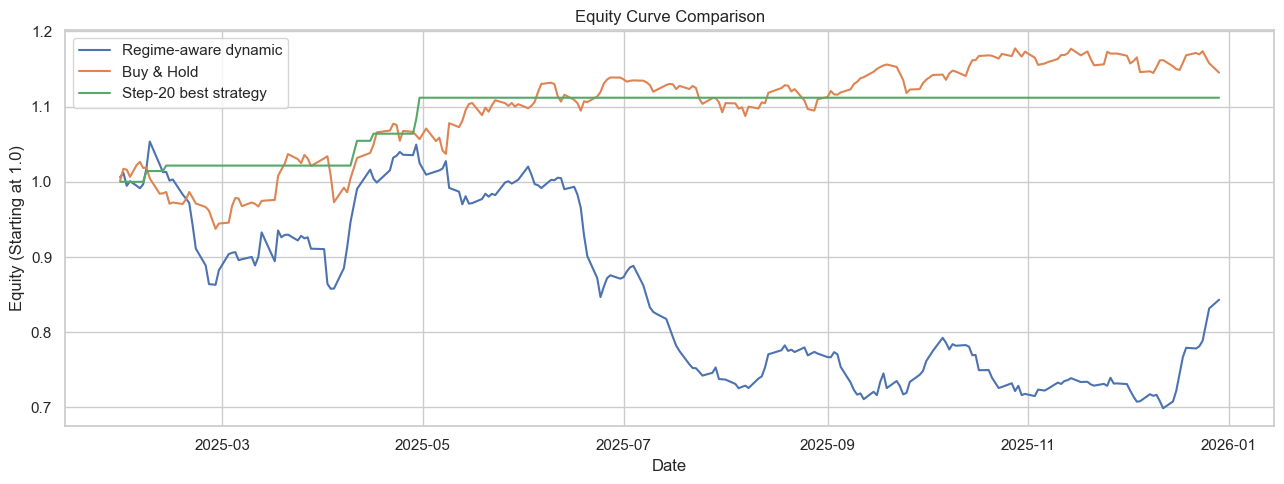

,Strategy,Total return,Sharpe ratio,Max drawdown,Win rate,Trades
0,LOW,-0.1818,-1.1102,-0.3787,0.4915,1561
1,MEDIUM,0.1985,1.4492,-0.0787,0.5075,800
2,HIGH,0.0692,18.9236,0.0000,1.0000,2


Saved strategy output: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\final_regime_aware_strategy.parquet
Done: regime-aware dynamic trading system built and evaluated.


In [4]:
def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    dd = equity / running_max - 1.0
    return float(dd.min()) if len(dd) else np.nan


def sharpe_ratio(daily_returns: pd.Series, annualization: int = ANNUALIZATION_DAYS) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0 or np.isnan(sigma):
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def summarize_strategy(name: str, daily_returns: pd.Series) -> Dict[str, float]:
    daily = daily_returns.sort_index()
    if len(daily) == 0:
        return {
            'Strategy': name,
            'Total return': np.nan,
            'Sharpe ratio': np.nan,
            'Max drawdown': np.nan,
            'Win rate': np.nan,
        }

    equity = (1.0 + daily).cumprod()
    return {
        'Strategy': name,
        'Total return': float(equity.iloc[-1] - 1.0),
        'Sharpe ratio': sharpe_ratio(daily),
        'Max drawdown': max_drawdown(equity),
        'Win rate': float((daily > 0).mean()),
    }


bh_df = infer_df.copy()
bh_df = bh_df.dropna(subset=['fwd_ret_t1'])
bh_df['bh_weight'] = 1.0 / bh_df.groupby('Date')['Ticker'].transform('count')
bh_df['bh_return'] = bh_df['bh_weight'] * bh_df['fwd_ret_t1']
daily_bh = bh_df.groupby('Date', as_index=True)['bh_return'].sum().sort_index()

step20 = pd.read_parquet(STEP20_PATH).copy()
step20['Date'] = pd.to_datetime(step20['Date'])
daily_step20 = step20.groupby('Date', as_index=True)['net_return'].sum().sort_index()

daily_regime_aware = daily_strategy.set_index('Date')['strategy_return'].sort_index()

common_index = daily_regime_aware.index.intersection(daily_bh.index).intersection(daily_step20.index)
daily_regime_aware_cmp = daily_regime_aware.loc[common_index]
daily_bh_cmp = daily_bh.loc[common_index]
daily_step20_cmp = daily_step20.loc[common_index]

metrics = pd.DataFrame([
    summarize_strategy('Regime-aware dynamic', daily_regime_aware_cmp),
    summarize_strategy('Buy & Hold', daily_bh_cmp),
    summarize_strategy('Step-20 best strategy', daily_step20_cmp),
]).sort_values('Sharpe ratio', ascending=False).reset_index(drop=True)

display(metrics.round(4))

equity_curves = pd.DataFrame({
    'Regime-aware dynamic': (1.0 + daily_regime_aware_cmp).cumprod(),
    'Buy & Hold': (1.0 + daily_bh_cmp).cumprod(),
    'Step-20 best strategy': (1.0 + daily_step20_cmp).cumprod(),
})

plt.figure(figsize=(13, 5))
for col in equity_curves.columns:
    plt.plot(equity_curves.index, equity_curves[col], label=col)
plt.title('Equity Curve Comparison')
plt.xlabel('Date')
plt.ylabel('Equity (Starting at 1.0)')
plt.legend()
plt.tight_layout()
plt.show()

regime_daily = sig_df[sig_df['selected_trade']].groupby(['Date', 'regime_label'], as_index=False)['strategy_return'].sum()
regime_perf_rows = []
for reg in REGIMES:
    reg_daily = regime_daily.loc[regime_daily['regime_label'] == reg, ['Date', 'strategy_return']].set_index('Date')['strategy_return'].sort_index()
    rec = summarize_strategy(reg, reg_daily)
    rec['Trades'] = int(sig_df[(sig_df['selected_trade']) & (sig_df['regime_label'] == reg)].shape[0])
    regime_perf_rows.append(rec)

regime_analysis = pd.DataFrame(regime_perf_rows)
display(regime_analysis.round(4))

save_cols = [
    'Ticker', 'Date', 'regime_label', 'horizon_days', 'probability',
    'signal_raw', 'signal_z', 'signal_rank', 'signal_norm',
    'is_center_weak', 'selected_trade', 'direction',
    'raw_weight', 'weight', 'future_return', 'strategy_return'
]
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
sig_df[save_cols].to_parquet(OUT_PATH, index=False)

print(f'Saved strategy output: {OUT_PATH}')
print('Done: regime-aware dynamic trading system built and evaluated.')
